# PSA System Simulator — Comprehensive Test

| Section | Content |
|---|---|
| 1. Random 100 cases | Scan over physically reasonable parameter range (physical + cost metrics) |
| 2. Physical consistency | Mass balance, metric range, cycle schedule checks |
| 3. Cost verification | Independent step-by-step recalculation of vessel + adsorbent CAPEX |
| 4. Error handling | Confirm penalty is returned for invalid inputs |

| Parameter | Sampling range |
|---|---|
| `D_col`            | 1.0–2.5 m |
| `L_bed`            | 4.0–12.0 m |
| `desorption_target`| 0.20–0.50 |
| `F_H2`             | 80–120 kmol/h |
| `F_CH4`            | 3–8 kmol/h |
| `F_C2H4`           | 1–4 kmol/h |
| `F_C2H6`           | 0.5–2 kmol/h |
| `T_in`             | 300–400 K |
| `P_in`             | 15–25 bar |

In [1]:
import os, sys, math, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

warnings.filterwarnings('ignore', category=UserWarning)

from units.separators.psa.psa_system import (
    PSADesignVars, PSAFeedStream, PSAFixedParams,
    simulate_psa_system,
)
from src.cost_calculator import calc_cp0, calc_fp, calc_reactor_capex_okuyen
from src.cost_parameters import (
    K1, K2, K3, B1, B2, FM, K_SWING,
    CEPCI_BASE, CEPCI_CURRENT,
    USD_TO_JPY, PLANT_INDIRECT_FACTOR,
    ACTIVATED_CARBON_PRICE_USD_PER_KG, ADSORBENT_LIFETIME_YEARS,
)

PASS_STR = 'PASS'
FAIL_STR = 'FAIL'

---
## Section 1 — Random 100 Cases

In [2]:
N   = 100
rng = np.random.default_rng(42)

D_col_arr      = rng.uniform(1.0,   2.5,  N)
L_bed_arr      = rng.uniform(4.0,  12.0,  N)
des_target_arr = rng.uniform(0.20,  0.50, N)
F_H2_arr       = rng.uniform(80.0, 120.0, N)
F_CH4_arr      = rng.uniform( 3.0,   8.0, N)
F_C2H4_arr     = rng.uniform( 1.0,   4.0, N)
F_C2H6_arr     = rng.uniform( 0.5,   2.0, N)
T_in_arr       = rng.uniform(300.0, 400.0, N)
P_in_arr       = rng.uniform( 15e5,  25e5, N)

fixed   = PSAFixedParams()
results = []

for i in range(N):
    design = PSADesignVars(
        D_col             = float(D_col_arr[i]),
        L_bed             = float(L_bed_arr[i]),
        desorption_target = float(des_target_arr[i]),
    )
    feed = PSAFeedStream(
        F_in = {
            'A': 0.0, 'B': 0.0,
            'C': float(F_H2_arr[i]),
            'D': float(F_C2H4_arr[i]),
            'E': float(F_CH4_arr[i]),
            'F': float(F_C2H6_arr[i]),
        },
        T_in = float(T_in_arr[i]),
        P_in = float(P_in_arr[i]),
    )

    status    = 'ok'
    h2rec     = ch4cap = t_abs = t_des = u0 = np.nan
    n_tot     = np.nan
    capex     = capex_ves = capex_ads = np.nan
    w_ads     = bd_loss = p_loss = np.nan
    prod_h2   = prod_ch4 = off_ch4 = np.nan
    error_msg = ''

    try:
        r = simulate_psa_system(design, feed, fixed)
        eq       = r.equipment
        h2rec    = r.H2_recovery
        ch4cap   = r.CH4_capture
        t_abs    = eq.t_abs_sec
        t_des    = eq.t_des_sec
        u0       = eq.u_0
        n_tot    = eq.N_total_columns
        capex    = eq.CAPEX_total
        capex_ves = eq.CAPEX_vessels
        capex_ads = eq.CAPEX_adsorbent
        w_ads    = eq.W_adsorbent_kg
        bd_loss  = eq.H2_loss_blowdown_kmolh
        p_loss   = eq.H2_loss_purge_kmolh
        prod_h2  = r.product.get('C', np.nan)
        prod_ch4 = r.product.get('E', np.nan)
        off_ch4  = r.offgas.get('E', np.nan)
        if capex >= 1e8:
            status = 'penalty'
    except Exception as e:
        status    = 'error'
        error_msg = f'{type(e).__name__}: {e}'

    results.append({
        'i'             : i,
        'D_col'         : D_col_arr[i],
        'L_bed'         : L_bed_arr[i],
        'des_target'    : des_target_arr[i],
        'F_H2_in'       : F_H2_arr[i],
        'F_CH4_in'      : F_CH4_arr[i],
        'T_in_K'        : T_in_arr[i],
        'P_in_bar'      : P_in_arr[i] / 1e5,
        'status'        : status,
        'H2_recovery'   : h2rec,
        'CH4_capture'   : ch4cap,
        't_abs_s'       : t_abs,
        't_des_s'       : t_des,
        'u_0_ms'        : u0,
        'N_total'       : n_tot,
        'CAPEX_total'   : capex,
        'CAPEX_vessels' : capex_ves,
        'CAPEX_ads'     : capex_ads,
        'W_ads_kg'      : w_ads,
        'BD_loss'       : bd_loss,
        'P_loss'        : p_loss,
        'F_H2_prod'     : prod_h2,
        'F_CH4_prod'    : prod_ch4,
        'F_CH4_off'     : off_ch4,
        'error_msg'     : error_msg,
    })

    if (i + 1) % 10 == 0:
        print(f'{i+1:3d}/100 complete')

df    = pd.DataFrame(results)
df_ok = df[df['status'] == 'ok'].copy()
print(f'\nDone  ok:{len(df_ok)}  penalty:{(df["status"]=="penalty").sum()}  error:{(df["status"]=="error").sum()}')

 10/100 complete
 20/100 complete
 30/100 complete
 40/100 complete
 50/100 complete
 60/100 complete
 70/100 complete
 80/100 complete
 90/100 complete
100/100 complete

Done  ok:100  penalty:0  error:0


In [3]:
print('=== Status breakdown ===')
print(df['status'].value_counts().to_string())
print()
print(f'=== Physical metrics ({len(df_ok)} ok cases) ===')
print(df_ok[['H2_recovery','CH4_capture','t_abs_s','t_des_s','u_0_ms']].describe().round(4).to_string())
print()
print(f'=== Cost / equipment metrics ({len(df_ok)} ok cases) ===')
print(df_ok[['CAPEX_total','CAPEX_vessels','CAPEX_ads','N_total','W_ads_kg']].describe().round(4).to_string())

df_err = df[df['status'] == 'error']
if len(df_err) > 0:
    print()
    print('=== Error cases ===')
    print(df_err[['i','D_col','L_bed','des_target','error_msg']].to_string())

=== Status breakdown ===
status
ok    100

=== Physical metrics (100 ok cases) ===
       H2_recovery  CH4_capture    t_abs_s   t_des_s    u_0_ms
count     100.0000     100.0000   100.0000  100.0000  100.0000
mean        0.8285       1.0000  1338.7669   79.3215    0.0200
std         0.0444       0.0000   885.3733   20.6771    0.0117
min         0.6315       0.9999   115.1547   47.1411    0.0070
25%         0.8079       1.0000   582.6802   61.0347    0.0109
50%         0.8361       1.0000  1172.9135   75.4007    0.0167
75%         0.8613       1.0000  1982.9906   99.2214    0.0256
max         0.8836       1.0000  4739.5732  119.2772    0.0526

=== Cost / equipment metrics (100 ok cases) ===
       CAPEX_total  CAPEX_vessels  CAPEX_ads  N_total    W_ads_kg
count     100.0000       100.0000   100.0000    100.0    100.0000
mean        1.3397         1.0423     0.2973      2.0  23414.2983
std         0.6820         0.5338     0.1527      0.0  12025.9495
min         0.3382         0.2681    

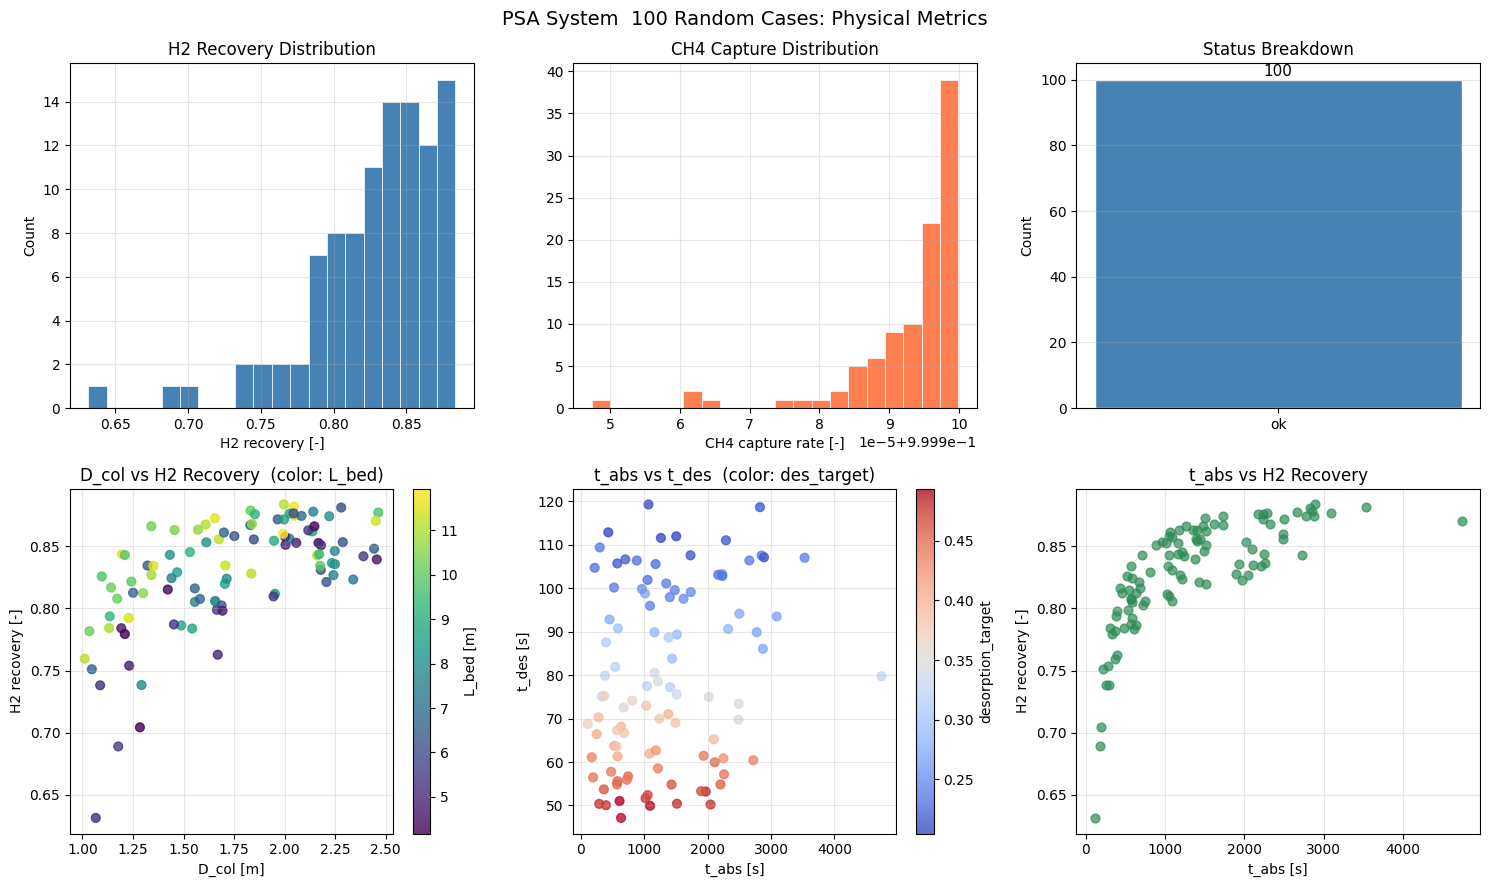

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('PSA System  100 Random Cases: Physical Metrics', fontsize=14)
STATUS_COLORS = {'ok': 'steelblue', 'penalty': 'orange', 'error': 'crimson'}

axes[0,0].hist(df_ok['H2_recovery'].dropna(), bins=20, color='steelblue', edgecolor='white', lw=0.5)
axes[0,0].set_xlabel('H2 recovery [-]'); axes[0,0].set_ylabel('Count')
axes[0,0].set_title('H2 Recovery Distribution'); axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(df_ok['CH4_capture'].dropna(), bins=20, color='coral', edgecolor='white', lw=0.5)
axes[0,1].set_xlabel('CH4 capture rate [-]')
axes[0,1].set_title('CH4 Capture Distribution'); axes[0,1].grid(True, alpha=0.3)

sc = df['status'].value_counts()
bars = axes[0,2].bar(sc.index, sc.values,
                     color=[STATUS_COLORS.get(s,'gray') for s in sc.index], edgecolor='white')
for bar, val in zip(bars, sc.values):
    axes[0,2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                   str(val), ha='center', va='bottom', fontsize=11)
axes[0,2].set_title('Status Breakdown'); axes[0,2].set_ylabel('Count')
axes[0,2].grid(True, alpha=0.3, axis='y')

sc0 = axes[1,0].scatter(df_ok['D_col'], df_ok['H2_recovery'],
                         c=df_ok['L_bed'], cmap='viridis', s=40, alpha=0.8)
plt.colorbar(sc0, ax=axes[1,0], label='L_bed [m]')
axes[1,0].set_xlabel('D_col [m]'); axes[1,0].set_ylabel('H2 recovery [-]')
axes[1,0].set_title('D_col vs H2 Recovery  (color: L_bed)'); axes[1,0].grid(True, alpha=0.3)

sc1 = axes[1,1].scatter(df_ok['t_abs_s'], df_ok['t_des_s'],
                         c=df_ok['des_target'], cmap='coolwarm', s=40, alpha=0.8)
plt.colorbar(sc1, ax=axes[1,1], label='desorption_target')
axes[1,1].set_xlabel('t_abs [s]'); axes[1,1].set_ylabel('t_des [s]')
axes[1,1].set_title('t_abs vs t_des  (color: des_target)'); axes[1,1].grid(True, alpha=0.3)

axes[1,2].scatter(df_ok['t_abs_s'], df_ok['H2_recovery'], alpha=0.7, color='seagreen', s=40)
axes[1,2].set_xlabel('t_abs [s]'); axes[1,2].set_ylabel('H2 recovery [-]')
axes[1,2].set_title('t_abs vs H2 Recovery'); axes[1,2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

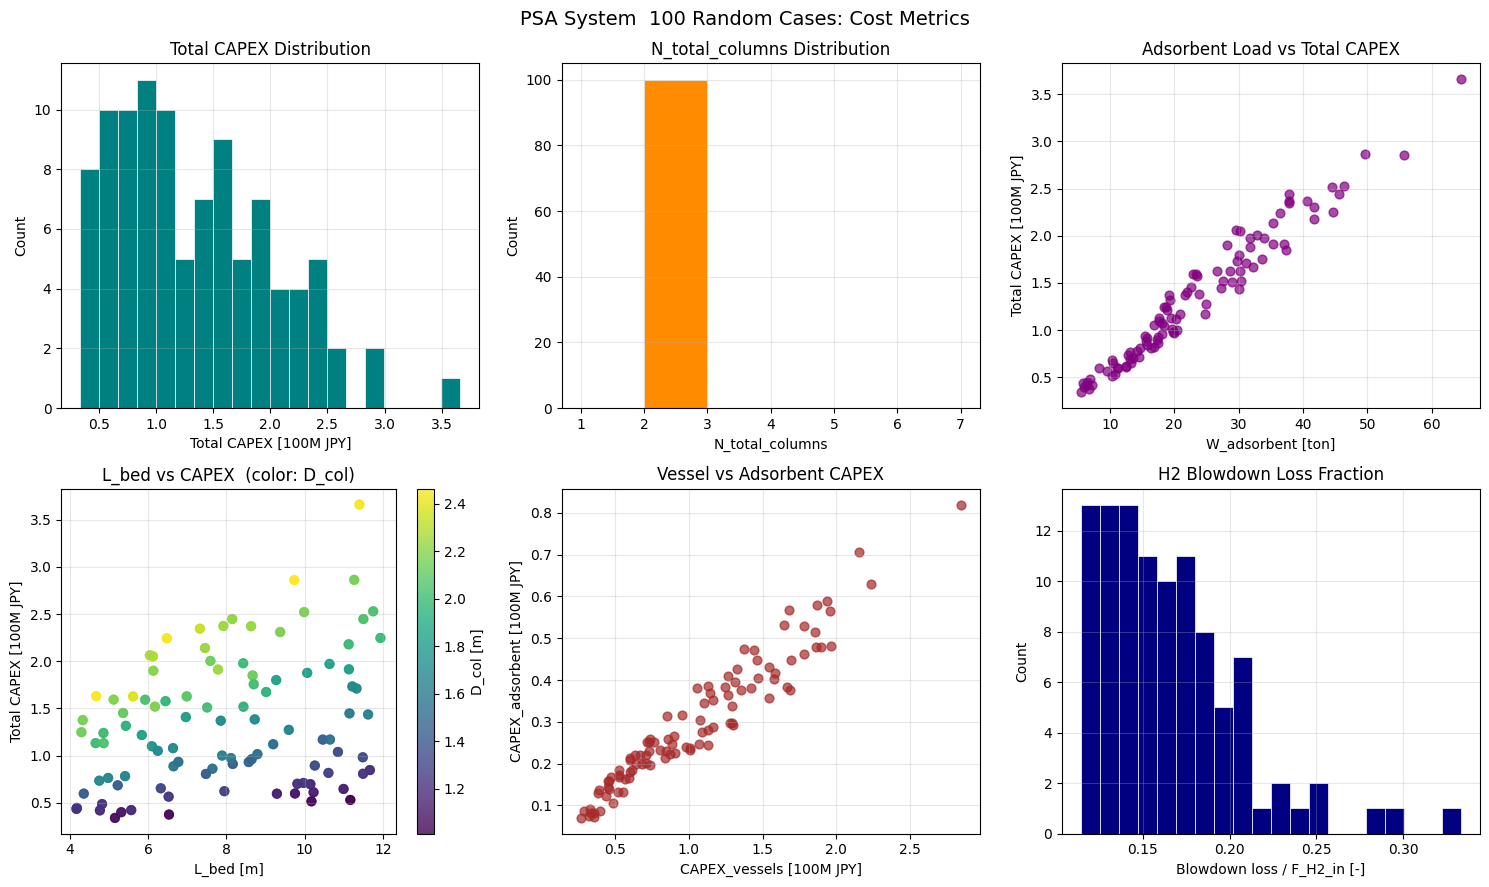

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('PSA System  100 Random Cases: Cost Metrics', fontsize=14)

axes[0,0].hist(df_ok['CAPEX_total'].dropna(), bins=20, color='teal', edgecolor='white', lw=0.5)
axes[0,0].set_xlabel('Total CAPEX [100M JPY]'); axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Total CAPEX Distribution'); axes[0,0].grid(True, alpha=0.3)

axes[0,1].hist(df_ok['N_total'].dropna(), bins=range(1, 8), color='darkorange', edgecolor='white', lw=0.5)
axes[0,1].set_xlabel('N_total_columns'); axes[0,1].set_ylabel('Count')
axes[0,1].set_title('N_total_columns Distribution'); axes[0,1].grid(True, alpha=0.3)

axes[0,2].scatter(df_ok['W_ads_kg']/1000, df_ok['CAPEX_total'], alpha=0.7, color='purple', s=40)
axes[0,2].set_xlabel('W_adsorbent [ton]'); axes[0,2].set_ylabel('Total CAPEX [100M JPY]')
axes[0,2].set_title('Adsorbent Load vs Total CAPEX'); axes[0,2].grid(True, alpha=0.3)

axes[1,0].scatter(df_ok['L_bed'], df_ok['CAPEX_total'],
                  c=df_ok['D_col'], cmap='viridis', s=40, alpha=0.8)
sc2 = axes[1,0].scatter(df_ok['L_bed'], df_ok['CAPEX_total'],
                         c=df_ok['D_col'], cmap='viridis', s=40, alpha=0.8)
plt.colorbar(sc2, ax=axes[1,0], label='D_col [m]')
axes[1,0].set_xlabel('L_bed [m]'); axes[1,0].set_ylabel('Total CAPEX [100M JPY]')
axes[1,0].set_title('L_bed vs CAPEX  (color: D_col)'); axes[1,0].grid(True, alpha=0.3)

axes[1,1].scatter(df_ok['CAPEX_vessels'], df_ok['CAPEX_ads'], alpha=0.7, color='brown', s=40)
axes[1,1].set_xlabel('CAPEX_vessels [100M JPY]'); axes[1,1].set_ylabel('CAPEX_adsorbent [100M JPY]')
axes[1,1].set_title('Vessel vs Adsorbent CAPEX'); axes[1,1].grid(True, alpha=0.3)

df_ok2 = df_ok.copy()
df_ok2['BD_frac'] = df_ok['BD_loss'] / df_ok['F_H2_in']
axes[1,2].hist(df_ok2['BD_frac'].dropna(), bins=20, color='navy', edgecolor='white', lw=0.5)
axes[1,2].set_xlabel('Blowdown loss / F_H2_in [-]'); axes[1,2].set_ylabel('Count')
axes[1,2].set_title('H2 Blowdown Loss Fraction'); axes[1,2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

---
## Section 2 — Physical Consistency Checks

Conditions that must hold for all physically valid results.

In [6]:
checks = []

def chk(label, series_bool, note=''):
    passed = bool(series_bool.all())
    n_fail = int((~series_bool).sum())
    checks.append({'Test': label,
                   'Result': PASS_STR if passed else FAIL_STR,
                   'Failures': 0 if passed else n_fail,
                   'Note': note})
    return passed

chk('0 <= H2_recovery <= 1',
    df_ok['H2_recovery'].between(0.0, 1.0), 'H2 回収率は [0,1]')
chk('0 <= CH4_capture <= 1',
    df_ok['CH4_capture'].between(0.0, 1.0), 'CH4 捕捉率は [0,1]')
chk('N_total_columns >= 2',
    df_ok['N_total'] >= 2, '最低 2 塔 (吸着 1 + 脱着 1)')
chk('t_abs_s > 0',
    df_ok['t_abs_s'] > 0.0, '吸着時間は正値')
chk('t_des_s > 0',
    df_ok['t_des_s'] > 0.0, '脱着時間は正値')
chk('u_0 <= 1.0 m/s',
    df_ok['u_0_ms'] <= 1.0, '空塔速度上限 _U0_MAX=1.0 m/s を超えない')
chk('CAPEX_total > 0',
    df_ok['CAPEX_total'] > 0.0, '有効な機器コストは正値')
chk('W_ads_kg > 0',
    df_ok['W_ads_kg'] > 0.0, '吸着材重量は正値')

# H2 質量収支: product_H2 + (BD_loss + P_loss) = F_H2_in  (exact)
h2_bal = (
    (df_ok['F_H2_prod'] + df_ok['BD_loss'] + df_ok['P_loss'] - df_ok['F_H2_in']).abs()
    / df_ok['F_H2_in'] < 1e-6
)
chk('H2 質量収支 (相対誤差 < 1e-6)', h2_bal, 'product + BD_loss + P_loss = F_H2_in')

# CH4 質量収支: product_CH4 + offgas_CH4 ≈ F_CH4_in  (ODE 数値積分誤差を許容)
ch4_bal = (
    (df_ok['F_CH4_prod'] + df_ok['F_CH4_off'] - df_ok['F_CH4_in']).abs()
    / df_ok['F_CH4_in'] < 1e-4
)
chk('CH4 質量収支 (相対誤差 < 1e-4)', ch4_bal, '数値積分誤差を含む全体収支')

df_checks = pd.DataFrame(checks)
print(df_checks.to_string(index=False))
n_phys_fail = (df_checks['Result'] == FAIL_STR).sum()
print()
print(f'==> {len(checks) - n_phys_fail}/{len(checks)} checks PASS')

                  Test Result  Failures                                 Note
 0 <= H2_recovery <= 1   PASS         0                        H2 回収率は [0,1]
 0 <= CH4_capture <= 1   PASS         0                       CH4 捕捉率は [0,1]
  N_total_columns >= 2   PASS         0                 最低 2 塔 (吸着 1 + 脱着 1)
           t_abs_s > 0   PASS         0                              吸着時間は正値
           t_des_s > 0   PASS         0                              脱着時間は正値
        u_0 <= 1.0 m/s   PASS         0         空塔速度上限 _U0_MAX=1.0 m/s を超えない
       CAPEX_total > 0   PASS         0                          有効な機器コストは正値
          W_ads_kg > 0   PASS         0                             吸着材重量は正値
 H2 質量収支 (相対誤差 < 1e-6)   PASS         0 product + BD_loss + P_loss = F_H2_in
CH4 質量収支 (相対誤差 < 1e-4)   PASS         0                        数値積分誤差を含む全体収支

==> 10/10 checks PASS


---
## Section 3 — Cost Formula Verification

**PSA 塔体 CAPEX (calc_reactor_capex_okuyen):**
```
V_col = pi/4 * D_col^2 * L_bed
Cp0 = 10^(K1 + K2*log10(V) + K3*log10(V)^2)
Fp  = calc_fp(P_gauge, D_col)
FBM = B1 + B2*Fp*FM
CBM = Cp0 * FBM * K_SWING
CAPEX_vessels = PLANT_INDIRECT_FACTOR * CBM * (CEPCI_CURRENT/CEPCI_BASE) * N_total * USD_TO_JPY / 1e8
```

**吸着材 CAPEX:**
```
CAPEX_adsorbent = W_ads_kg * ACTIVATED_CARBON_PRICE * (CEPCI_CURRENT/CEPCI_BASE)
                  * PLANT_INDIRECT_FACTOR * USD_TO_JPY / 1e8
```

In [7]:
row   = df_ok.iloc[0]
i_idx = int(row['i'])
D_c   = float(D_col_arr[i_idx])
L_b   = float(L_bed_arr[i_idx])
P_pa  = float(P_in_arr[i_idx])
N_tot = int(row['N_total'])
W_kg  = row['W_ads_kg']
capex_sim_ves = row['CAPEX_vessels']
capex_sim_ads = row['CAPEX_ads']
capex_sim_tot = row['CAPEX_total']

V_col = math.pi / 4.0 * D_c**2 * L_b

print(f'Case: i={i_idx}')
print(f'  D_col = {D_c:.4f} m,  L_bed = {L_b:.4f} m,  V_col = {V_col:.4f} m3')
print(f'  P_in  = {P_pa/1e5:.4f} bar abs')
print(f'  N_total_columns = {N_tot},  W_adsorbent_kg = {W_kg:.2f} kg')
print()

capex_ves_calc = calc_reactor_capex_okuyen(V_col, P_pa, D_c, N_tot)
P_gauge_bar    = P_pa / 1e5 - 1.01325
cp0            = calc_cp0(V_col)
fp             = calc_fp(P_gauge_bar, D_c)
fbm            = B1 + B2 * fp * FM
cbm            = cp0 * fbm * K_SWING

print('--- 塔体 CAPEX (vessels) ---')
print(f'  log10(V_col)     = {math.log10(V_col):.6f}')
print(f'  Cp0              = {cp0:>12,.1f} USD  (K1={K1}, K2={K2}, K3={K3})')
print(f'  P_gauge          = {P_gauge_bar:.4f} bar')
print(f'  Fp               = {fp:.6f}')
print(f'  FBM              = {fbm:.6f}  (B1={B1}, B2={B2}, FM={FM})')
print(f'  CBM (x K_swing)  = {cbm:>12,.1f} USD  (K_swing={K_SWING})')
print(f'  CAPEX_ves (calc) = {capex_ves_calc:.8f} oku-yen')
print(f'  CAPEX_ves (sim)  = {capex_sim_ves:.8f} oku-yen')
err_ves = abs(capex_ves_calc - capex_sim_ves)
print(f'  abs error        = {err_ves:.2e}  =>  {PASS_STR if err_ves < 1e-9 else FAIL_STR}')
print()

capex_ads_calc = (
    W_kg * ACTIVATED_CARBON_PRICE_USD_PER_KG
    * (CEPCI_CURRENT / CEPCI_BASE)
    * PLANT_INDIRECT_FACTOR * USD_TO_JPY / 1.0e8
)
print('--- 吸着材 CAPEX (adsorbent) ---')
print(f'  W_ads_kg                 = {W_kg:.2f} kg')
print(f'  ACTIVATED_CARBON_PRICE   = {ACTIVATED_CARBON_PRICE_USD_PER_KG} USD/kg  (placeholder)')
print(f'  CEPCI factor             = {CEPCI_CURRENT/CEPCI_BASE:.6f}  ({CEPCI_CURRENT}/{CEPCI_BASE})')
print(f'  PLANT_INDIRECT_FACTOR    = {PLANT_INDIRECT_FACTOR}')
print(f'  CAPEX_ads (calc)         = {capex_ads_calc:.8f} oku-yen')
print(f'  CAPEX_ads (sim)          = {capex_sim_ads:.8f} oku-yen')
err_ads = abs(capex_ads_calc - capex_sim_ads)
print(f'  abs error                = {err_ads:.2e}  =>  {PASS_STR if err_ads < 1e-9 else FAIL_STR}')
print()

capex_tot_calc = capex_ves_calc + capex_ads_calc
err_tot        = abs(capex_tot_calc - capex_sim_tot)
print('--- 合計 CAPEX ---')
print(f'  CAPEX_total (calc) = {capex_tot_calc:.8f} oku-yen')
print(f'  CAPEX_total (sim)  = {capex_sim_tot:.8f} oku-yen')
print(f'  abs error          = {err_tot:.2e}  =>  {PASS_STR if err_tot < 1e-9 else FAIL_STR}')

Case: i=0
  D_col = 2.1609 m,  L_bed = 11.2686 m,  V_col = 41.3280 m3
  P_in  = 22.3858 bar abs
  N_total_columns = 2,  W_adsorbent_kg = 49593.63 kg

--- 塔体 CAPEX (vessels) ---
  log10(V_col)     = 1.616245
  Cp0              =     31,830.3 USD  (K1=3.4974, K2=0.4485, K3=0.1074)
  P_gauge          = 21.3726 bar
  Fp               = 5.086495
  FBM              = 11.507420  (B1=2.25, B2=1.82, FM=1.0)
  CBM (x K_swing)  =    439,541.9 USD  (K_swing=1.2)
  CAPEX_ves (calc) = 2.23275733 oku-yen
  CAPEX_ves (sim)  = 2.23275733 oku-yen
  abs error        = 0.00e+00  =>  PASS

--- 吸着材 CAPEX (adsorbent) ---
  W_ads_kg                 = 49593.63 kg
  ACTIVATED_CARBON_PRICE   = 5.0 USD/kg  (placeholder)
  CEPCI factor             = 1.370277  (544.0/397.0)
  PLANT_INDIRECT_FACTOR    = 1.18
  CAPEX_ads (calc)         = 0.62980656 oku-yen
  CAPEX_ads (sim)          = 0.62980656 oku-yen
  abs error                = 0.00e+00  =>  PASS

--- 合計 CAPEX ---
  CAPEX_total (calc) = 2.86256389 oku-yen
  CAPEX

---
## Section 4 — Error Handling Verification

Expected penalty values:
- `CAPEX_total = 1e9` [100M JPY]
- `H2_recovery = 0.0`
- `CH4_capture = 0.0`

In [8]:
_PENALTY_CAPEX = 1e9

valid_design = PSADesignVars(D_col=1.5, L_bed=7.0, desorption_target=0.35)
valid_feed   = PSAFeedStream(
    F_in={'A': 0.0, 'B': 0.0, 'C': 100.0, 'D': 2.0, 'E': 5.0, 'F': 1.0},
    T_in=350.0, P_in=20.0e5,
)
_fixed = PSAFixedParams()

def _run(label, d, f):
    try:
        r = simulate_psa_system(d, f, _fixed)
        ok = (abs(r.equipment.CAPEX_total - _PENALTY_CAPEX) < 1.0
              and r.H2_recovery == 0.0
              and r.CH4_capture == 0.0)
        return {'Case': label,
                'Result': PASS_STR if ok else FAIL_STR,
                'CAPEX'  : f'{r.equipment.CAPEX_total:.1e}',
                'H2_rec' : r.H2_recovery,
                'CH4_cap': r.CH4_capture}
    except Exception as e:
        return {'Case': label, 'Result': f'{FAIL_STR} exception:{e}',
                'CAPEX': '-', 'H2_rec': '-', 'CH4_cap': '-'}

def _d(**kw):
    d = copy.deepcopy(valid_design)
    for k, v in kw.items(): setattr(d, k, v)
    return d

rows_eh = [
    _run('F_CH4 = 0 (breakthrough undetectable)',
         valid_design,
         PSAFeedStream(F_in={'A':0,'B':0,'C':100,'D':2,'E':0,'F':1},
                       T_in=350., P_in=20e5)),
    _run('desorption_target = 1.0 (t_abs_css=0)',
         _d(desorption_target=1.0), valid_feed),
    _run('D_col = 0.05 m (u_0 >> U0_MAX=1.0)',
         _d(D_col=0.05), valid_feed),
    _run('D_col=0.5, L_bed=2.0 (t_abs_css < T_ABS_MIN=60s)',
         PSADesignVars(D_col=0.5, L_bed=2.0, desorption_target=0.35), valid_feed),
    _run('Large F_H2=5000 kmol/h (u_0 >> U0_MAX)',
         valid_design,
         PSAFeedStream(F_in={'A':0,'B':0,'C':5000,'D':50,'E':100,'F':20},
                       T_in=350., P_in=20e5)),
]

df_eh = pd.DataFrame(rows_eh)
print(df_eh.to_string(index=False))
n_eh_pass = (df_eh['Result'] == PASS_STR).sum()
print()
print(f'==> {n_eh_pass}/{len(rows_eh)} cases PASS')

                                            Case Result   CAPEX  H2_rec  CH4_cap
           F_CH4 = 0 (breakthrough undetectable)   PASS 1.0e+09     0.0      0.0
           desorption_target = 1.0 (t_abs_css=0)   PASS 1.0e+09     0.0      0.0
              D_col = 0.05 m (u_0 >> U0_MAX=1.0)   PASS 1.0e+09     0.0      0.0
D_col=0.5, L_bed=2.0 (t_abs_css < T_ABS_MIN=60s)   PASS 1.0e+09     0.0      0.0
          Large F_H2=5000 kmol/h (u_0 >> U0_MAX)   PASS 1.0e+09     0.0      0.0

==> 5/5 cases PASS


In [9]:
print('=' * 62)
print('  PSA System Comprehensive Test - Summary')
print('=' * 62)

s1_err  = int((df['status'] == 'error').sum())
s1_ok   = len(df_ok)
s2_fail = int((df_checks['Result'] == FAIL_STR).sum())
s3_ok   = (err_ves < 1e-9 and err_ads < 1e-9 and err_tot < 1e-9)
s4_pass = int((df_eh['Result'] == PASS_STR).sum())

print(f'[Sec 1] Random 100 cases        : ok={s1_ok}/100  error={s1_err}/100')
print(f'[Sec 2] Physical consistency    : {len(checks)-s2_fail}/{len(checks)} checks PASS')
print(f'[Sec 3] Cost verification       : ves err={err_ves:.2e}  ads err={err_ads:.2e}  => {PASS_STR if s3_ok else FAIL_STR}')
print(f'[Sec 4] Error handling          : {s4_pass}/{len(rows_eh)} cases PASS')

all_ok = (s1_err == 0 and s2_fail == 0 and s3_ok and s4_pass == len(rows_eh))
print()
print('  => ALL PASS' if all_ok else '  => SOME FAILURES - check above')
print('=' * 62)

  PSA System Comprehensive Test - Summary
[Sec 1] Random 100 cases        : ok=100/100  error=0/100
[Sec 2] Physical consistency    : 10/10 checks PASS
[Sec 3] Cost verification       : ves err=0.00e+00  ads err=0.00e+00  => PASS
[Sec 4] Error handling          : 5/5 cases PASS

  => ALL PASS
